# Prediction-Based Inter-Cell Traffic Steering in LTE — Complete Pipeline

**MSc thesis · single-RAT (LTE), multi-cell · prediction-first, non-RL**

Forecast per-cell load, derive congestion by thresholding the forecast, steer load toward the
neighbour with the best *predicted* headroom, and measure whether that beats reacting.

| RQ | Question | Section |
|---|---|---|
| **RQ1** | How accurately can per-cell load be forecast, and how does accuracy change with horizon? | |
| **RQ2** | Does prediction-driven steering beat reactive and signal-only baselines? | |
| **RQ3** | Do spatial-neighbour features help? Does congestion derive cleanly from the forecast? |  |
| **RQ4** | KPI counters reach the management system ~1 h after generation. Does prediction survive that lead time, and does the delay explain why closed-loop RL stays simulation-bound? |  |

### How to run

Run top to bottom. To run against the controlled benchmark instead, set `PM_DATA=synthetic_realistic_pm_data.csv`
in the environment, or uncomment the `DATA_FILE` line in §0.1. Every metric row is stamped with the dataset it
came from, so both panels can share the result logs without colliding.

### Method invariants (held throughout)

- Temporal split **never random** — 70/15/15 by day boundary, same wall-clock cut for every cell.
- Scalers fit on **train only**.
- Every history/KPI feature shifted by ≥ Δ, so nothing leaks the future.
- Early stopping uses **validation**; the test day is scored exactly once per model.
- Two metric layers: prediction (`results.csv`) and system (`system_results.csv`).

---
##  Setup

### 0.1 Environment, constants, dataset

In [1]:
# Dependencies are installed in the project venv. Left commented so the notebook re-runs
#%pip install -q pandas numpy scikit-learn xgboost matplotlib seaborn scipy pyarrow joblib tensorflow

In [2]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from xgboost import XGBRegressor
from scipy.stats import wilcoxon
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             f1_score, precision_score, recall_score,
                             average_precision_score, confusion_matrix, precision_recall_curve)

SEED = 42
np.random.seed(SEED)

# --- targets & features ---------------------------------------------------
TARGET     = 'DL_PRB_UTIL_PCT'      # primary load target (already a %)
SECONDARY  = 'DL_CELL_THP_MBPS'     # secondary throughput target
RADIO_KPIS = ['ACTIVE_RRC_CONN_UES', 'AVG_CQI', 'AVG_SINR_DB', 'AVG_RSRP_DBM']

# --- time & horizon -------------------------------------------------------
SEASON     = 96        # 96 steps x 15 min = 1 day -> lag-96 is 'same time yesterday'
H_MAIN     = 1         # primary horizon, in steps (1 step = 15 min)
LEAD_TIMES = [1, 2, 4, 8]   # RQ4 sweep: 15 / 30 / 60 / 120 min

# The lead time the STEERING layer treats as headline. Section 4 argues that one ROP is not the
# operationally relevant point: a controller reads OSS state that is already ~4 ROPs stale, so
# Delta=4 (60 min) is the point a deployed system would actually run at. The steering layer now
# sweeps every entry of LEAD_TIMES; this only selects which one the headline table and the
# significance test report.
HEADLINE_LEAD = 4

# --- steering thresholds --------------------------------------------------
TAU      = 80.0        # congestion threshold, % PRB utilisation
RSRP_MIN = -110.0      # coverage floor for the steering constraint

# --- paths ----------------------------------------------------------------
DATA_DIR    = Path('.')
FIG_DIR     = Path('figures'); FIG_DIR.mkdir(exist_ok=True)
PROC_DIR    = Path('data');    PROC_DIR.mkdir(exist_ok=True)
RESULTS_CSV = Path('results.csv')          # prediction metrics
SYS_CSV     = Path('system_results.csv')   # steering / system metrics
STATS_CSV   = Path('stats_tests.csv')      # significance tests

# --- dataset switch -------------------------------------------------------
# SYNTHETIC but  derived from real customer samples as customer data is confidential;
# the benchmark is generated by generate_synthetic_realistic.py (see its datacard).
#DATA_FILE = os.environ.get('PM_DATA', 'smart_pm_data.csv')
DATA_FILE = 'synthetic_realistic_v3_pm_data.csv'   # <- controlled benchmark

print('pandas', pd.__version__, '| numpy', np.__version__)
print('dataset:', DATA_FILE)

pandas 3.0.3 | numpy 2.5.1
dataset: synthetic_realistic_v3_pm_data.csv


### 0.2 Helper Function library

 cleaning / feature engineering / split dataset / Metrics / Logging


In [3]:
# ─────────────────────────── data loading & cleaning ───────────────────────────
def load_clean_raw():
    """Read the panel, sort per cell, repair isolated missing bins, add calendar features.

    The panel contains isolated single-interval missing bins (~0.8 %). They must be repaired
    BEFORE feature engineering: a NaN cascades through rolling(96) (pandas defaults to
    min_periods=96, so one NaN nulls 96 windows) and a naive dropna afterwards would silently
    delete ~60 % of the panel. `target_observed` records which target values were genuinely
    measured, so an interpolated value is never used as a training label.
    """
    df = pd.read_csv(DATA_DIR / DATA_FILE, parse_dates=['startTime', 'endTime'])
    df = df.sort_values(['cellId', 'startTime']).reset_index(drop=True)
    impute = [TARGET, SECONDARY] + RADIO_KPIS
    df['target_observed'] = df[TARGET].notna()
    df[impute] = df.groupby('cellId', group_keys=False)[impute].apply(
        lambda b: b.interpolate(method='linear', limit=3, limit_area='inside'))
    df['hour'] = df['startTime'].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    return df


# ─────────────────────────── leakage-safe features ───────────────────────────
def engineer_features(df, H):
    """Build features that predict y_t using only information available at t-H.

    Δ = H is both the forecast horizon AND the OSS collection latency the forecast absorbs (RQ4):
    every history and KPI feature is shifted by at least H, so at H=4 the model predicts one hour
    ahead using only data that is already one hour old — the real operational situation.

    Rolling stats shift THEN roll, never the reverse, so the current value never enters its own window.
    Day-of-week is deliberately absent: a 7-day span contains 0 complete weekly cycles.
    """
    df = df.sort_values(['cellId', 'startTime']).reset_index(drop=True)
    g = df.groupby('cellId', group_keys=False)
    lags = sorted({H, H + 1, H + 2, SEASON})
    for L in lags:
        df[f'lag_{L}'] = g[TARGET].shift(L)
    df['roll_mean_4']  = g[TARGET].transform(lambda s: s.shift(H).rolling(4).mean())
    df['roll_std_4']   = g[TARGET].transform(lambda s: s.shift(H).rolling(4).std())
    df['roll_mean_96'] = g[TARGET].transform(lambda s: s.shift(H).rolling(SEASON).mean())
    df['roc'] = df[f'lag_{H}'] - df[f'lag_{H + 1}']              # rate of change
    for c in RADIO_KPIS:
        df[f'{c}_lag{H}'] = g[c].shift(H)
    df['pred_persistence'] = df[f'lag_{H}']                       # baseline: last observed
    df['pred_seasonal']    = df[f'lag_{SEASON}']                  # baseline: same time yesterday
    FEATURES = (['hour_sin', 'hour_cos', 'roll_mean_4', 'roll_std_4', 'roll_mean_96', 'roc']
                + [f'lag_{L}' for L in lags] + [f'{c}_lag{H}' for c in RADIO_KPIS])
    return df, FEATURES


def make_model_frame(df, FEATURES):
    """Keep only rows with a genuinely observed target and no NaN features (drops warm-up)."""
    return df[df['target_observed']].dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)


# ─────────────────────────── temporal split ───────────────────────────
def split_days(dfm, val_frac=0.70, test_frac=0.85):
    """70/15/15 by DAY boundary — same wall-clock cut for every cell, never random.

    Cut points are derived from the days that actually survive the warm-up drop (lag_96 /
    roll_mean_96 remove the entire first calendar day), rather than hard-coded indices.
    """
    days = sorted(dfm['startTime'].dt.normalize().unique()); n = len(days)
    i_val, i_test = int(round(n * val_frac)), int(round(n * test_frac))
    assert 0 < i_val < i_test < n, f'not enough days to split ({n})'
    tr = dfm[dfm['startTime'] < days[i_val]]
    va = dfm[(dfm['startTime'] >= days[i_val]) & (dfm['startTime'] < days[i_test])]
    te = dfm[dfm['startTime'] >= days[i_test]]
    assert tr['startTime'].max() < va['startTime'].min() < te['startTime'].min(), 'temporal order broken'
    info = dict(days=[str(pd.Timestamp(d).date()) for d in days],
                val_start=days[i_val], test_start=days[i_test])
    return tr, va, te, info



def add_cell(dfx, FEATURES):
    """Feature matrix + cellId as a categorical, so the pooled model can specialise per cell."""
    x = dfx[FEATURES].copy()
    x['cellId'] = dfx['cellId'].astype('category')
    return x


# ─────────────────────────── model & metrics ───────────────────────────
def new_xgb(seed=SEED):
    """Headline forecaster. Early stopping is driven by the VALIDATION set, never test."""
    return XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.8,
                        colsample_bytree=0.8, min_child_weight=3, tree_method='hist',
                        enable_categorical=True, random_state=seed, n_jobs=-1,
                        early_stopping_rounds=50, eval_metric='mae')


def reg_metrics(yt, yp):
    """MAE / RMSE / MAPE / R2 in ORIGINAL units (percentage points of PRB utilisation).

    No inverse-transform is needed: XGBoost consumes raw features (trees are scale-invariant);
    the saved scaler exists only for the sequence model in §7.
    MAPE is guarded to y_true > 1 to avoid dividing by near-zero denominators.
    """
    yt = np.asarray(yt, float); yp = np.asarray(yp, float); m = yt > 1.0
    return dict(MAE=float(mean_absolute_error(yt, yp)),
                RMSE=float(np.sqrt(mean_squared_error(yt, yp))),
                MAPE=float(np.mean(np.abs((yt[m] - yp[m]) / yt[m])) * 100),
                R2=float(r2_score(yt, yp)))


def jains(x):
    """Jain's fairness index of a load vector: 1.0 = perfectly even."""
    x = np.asarray(x, float)
    return float((x.sum() ** 2) / (len(x) * np.sum(x ** 2) + 1e-12))


# ─────────────────────────── result logging ───────────────────────────
# Canonical schema. Rows are reindexed onto it before appending, so an extra key can never
# shift values into the wrong column. `window` is NaN for non-sequence models.
RESULT_COLS = ['dataset', 'model', 'seed', 'horizon', 'window', 'target', 'split',
               'MAE', 'RMSE', 'MAPE', 'R2', 'ts']


def log_result(model, split, metrics, seed=SEED, horizon=H_MAIN, extra=None):
    """Append one PREDICTION-layer row to results.csv."""
    row = dict(dataset=DATA_FILE, model=model, seed=seed, horizon=horizon, window=None,
               target=TARGET, split=split, **{k: round(float(v), 4) for k, v in metrics.items()})
    if extra:
        unknown = set(extra) - set(RESULT_COLS)
        if unknown:
            raise KeyError(f'log_result: extra keys not in RESULT_COLS: {unknown}')
        row.update(extra)
    row['ts'] = pd.Timestamp.now()
    pd.DataFrame([row]).reindex(columns=RESULT_COLS).to_csv(
        RESULTS_CSV, mode='a', header=not RESULTS_CSV.exists(), index=False)
    return row


# System-layer schema. `model` records WHICH estimator drove the policy and `horizon` the lead
# time it was asked for. Both were previously fixed -- horizon was hard-coded to 1 and there was
# no model column at all -- so every steering result ever logged was implicitly (xgboost, 15 min)
# with no way to record another. Legacy rows were backfilled: they were all exactly that.
#   model = 'measured' for B0/B1 (they read measurements, not forecasts), 'oracle' for the
#   perfect-prediction ceiling, 'none' for no_steering, else the forecaster name.
SYS_COLS = ['ts', 'dataset', 'model', 'policy', 'seed', 'horizon', 'tau', 'rsrp_min',
            'thp_gain_pct', 'jain_fairness', 'congestion_incidence', 'handovers', 'pingpongs']


def log_system(m, seed=SEED, model='xgboost', horizon=H_MAIN):
    """Append one SYSTEM-layer row to system_results.csv (different schema from results.csv)."""
    row = dict(ts=pd.Timestamp.now(), dataset=DATA_FILE, model=model, policy=m['policy'],
               seed=seed, horizon=horizon, tau=TAU, rsrp_min=RSRP_MIN,
               thp_gain_pct=round(m['thp_gain_pct'], 4),
               jain_fairness=round(m['jain_fairness'], 4),
               congestion_incidence=round(m['congestion_incidence'], 4),
               handovers=m['handovers'], pingpongs=m['pingpongs'])
    pd.DataFrame([row]).reindex(columns=SYS_COLS).to_csv(
        SYS_CSV, mode='a', header=not SYS_CSV.exists(), index=False)
    return row


def log_stat(test, comparison, stat, p, n):
    """Append one significance-test row to stats_tests.csv."""
    row = dict(ts=pd.Timestamp.now(), dataset=DATA_FILE, test=test, comparison=comparison,
               statistic=round(float(stat), 4), p_value=float(p), n=int(n),
               tau=TAU, rsrp_min=RSRP_MIN)
    pd.DataFrame([row]).to_csv(STATS_CSV, mode='a', header=not STATS_CSV.exists(), index=False)
    return row


print('pipeline library defined')

pipeline library defined


---
### 1 - Data & quality

### 1.1 Load and sanity-check 

.

In [4]:
raw = load_clean_raw()

n_cells = raw['cellId'].nunique()
rows_per_cell = raw.groupby('cellId').size()
step_min = raw.groupby('cellId')['startTime'].diff().dropna().dt.total_seconds() / 60
n_missing = int((~raw['target_observed']).sum())

print('cells:', n_cells)
print('rows/cell (unique):', rows_per_cell.unique())
print('time range:', raw['startTime'].min(), '->', raw['startTime'].max())
print('cadence minutes -> mode:', step_min.mode().tolist(), '| min/max:', step_min.min(), step_min.max())
print('missing bins: %d (%.1f%% of rows) - isolated single intervals, interpolated per cell'
      % (n_missing, 100 * n_missing / len(raw)))
assert n_cells == 50 and rows_per_cell.nunique() == 1, 'expected 50 cells, equal rows each'
assert rows_per_cell.iloc[0] % 96 == 0, 'expected whole days at 15-min cadence'
print('panel span: %d days x 96 bins/day' % (rows_per_cell.iloc[0] // 96))
raw.head(3)

cells: 50
rows/cell (unique): [672]
time range: 2026-06-28 00:00:00 -> 2026-07-04 23:45:00
cadence minutes -> mode: [15.0] | min/max: 15.0 15.0
missing bins: 250 (0.7% of rows) - isolated single intervals, interpolated per cell
panel span: 7 days x 96 bins/day


,startTime,endTime,fdn,subNetwork,meContext,managedElement,kpiJobId,siteId,cellId,sector,...,DL_PRB_UTIL_PCT,ACTIVE_RRC_CONN_UES,DL_CELL_THP_MBPS,AVG_CQI,AVG_SINR_DB,AVG_RSRP_DBM,target_observed,hour,hour_sin,hour_cos
0,2026-06-28 00:00:00,2026-06-28 00:15:00,"SubNetwork=RootNetwork1,SubNetwork=SubNetwork1...","SubNetwork=RootNetwork1,SubNetwork=SubNetwork1",meContext01,1,ee3d8b22-e670-40b7-b63d-8f61799131e8,143,7,1,...,58.19,255.0,241.15,9.39,16.57,-82.17,True,0,0.0,1.0
1,2026-06-28 00:15:00,2026-06-28 00:30:00,"SubNetwork=RootNetwork1,SubNetwork=SubNetwork1...","SubNetwork=RootNetwork1,SubNetwork=SubNetwork1",meContext01,1,ee3d8b22-e670-40b7-b63d-8f61799131e8,143,7,1,...,61.10,257.0,261.90,10.25,18.33,-85.80,True,0,0.0,1.0
2,2026-06-28 00:30:00,2026-06-28 00:45:00,"SubNetwork=RootNetwork1,SubNetwork=SubNetwork1...","SubNetwork=RootNetwork1,SubNetwork=SubNetwork1",meContext01,1,ee3d8b22-e670-40b7-b63d-8f61799131e8,143,7,1,...,57.03,232.0,248.54,10.15,19.13,-80.90,True,0,0.0,1.0


### 1.2 Neighbour Cells

Kept as a **separate lookup**, deliberately never merged into the DF — it is the candidate set for the steering policy in section 8

In [5]:
nbr = pd.read_csv(DATA_DIR / 'smart_pm_neighbours.csv')
nbr = nbr[nbr['cellId'] != nbr['neighbourCellId']]
print('neighbour rows:', len(nbr), '| avg neighbours/cell:', round(len(nbr) / nbr['cellId'].nunique(), 1))
nbr.head()

neighbour rows: 400 | avg neighbours/cell: 8.0


,cellId,fdn,neighbourCellId,neighbourFdn,rank,distance_m,cosited,bearing_deg,azimuth_diff_deg
0,33,"SubNetwork=RootNetwork1,SubNetwork=SubNetwork1...",31,"SubNetwork=RootNetwork1,SubNetwork=SubNetwork1...",1,0.0,True,NaN,NaN
1,33,"SubNetwork=RootNetwork1,SubNetwork=SubNetwork1...",96,"SubNetwork=RootNetwork1,SubNetwork=SubNetwork1...",2,0.0,True,NaN,NaN
2,33,"SubNetwork=RootNetwork1,SubNetwork=SubNetwork1...",226,"SubNetwork=RootNetwork1,SubNetwork=SubNetwork1...",3,909.1,False,359.6,61.0
3,33,"SubNetwork=RootNetwork1,SubNetwork=SubNetwork1...",460,"SubNetwork=RootNetwork1,SubNetwork=SubNetwork1...",4,909.1,False,359.6,61.0
4,33,"SubNetwork=RootNetwork1,SubNetwork=SubNetwork1...",604,"SubNetwork=RootNetwork1,SubNetwork=SubNetwork1...",5,909.1,False,359.6,61.0


### 1.3 EDA Section

Four figures, each earning its place:

- **Per-cell load spread** - proves load imbalance exists, i.e. there is headroom to steer *into*.
 
- **Diurnal curve** - motivates the hour-of-day feature. 
- **Target distributions** - shows where the congestion threshold τ=80 % sits relative to the mass.
- **Correlation heatmap** - flags the SINR↔CQI redundancy which is again proven in 5.2 tests directly.

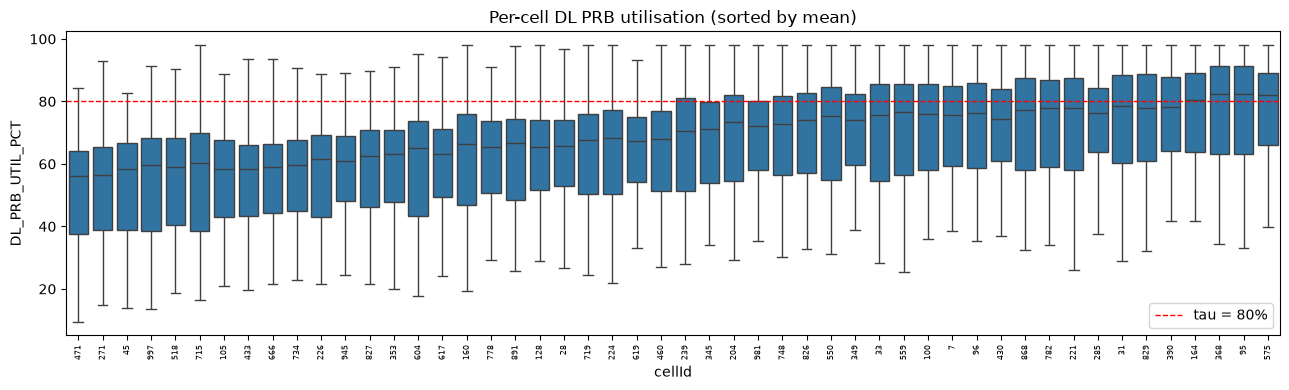

per-cell mean load: 51.5% - 78.0% (spread 26.5 pp)


In [6]:
# Per-cell load spread -> confirms imbalance (= headroom to steer into)
order = raw.groupby('cellId')[TARGET].mean().sort_values().index
plt.figure(figsize=(13, 4))
sns.boxplot(data=raw, x='cellId', y=TARGET, order=order, fliersize=1)
plt.xticks(rotation=90, fontsize=6); plt.title('Per-cell DL PRB utilisation (sorted by mean)')
plt.axhline(TAU, color='r', ls='--', lw=1, label=f'tau = {TAU:g}%'); plt.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / 'eda_percell_load.png', dpi=120); plt.show()

cm = raw.groupby('cellId')[TARGET].mean()
print('per-cell mean load: %.1f%% - %.1f%% (spread %.1f pp)' % (cm.min(), cm.max(), cm.max() - cm.min()))

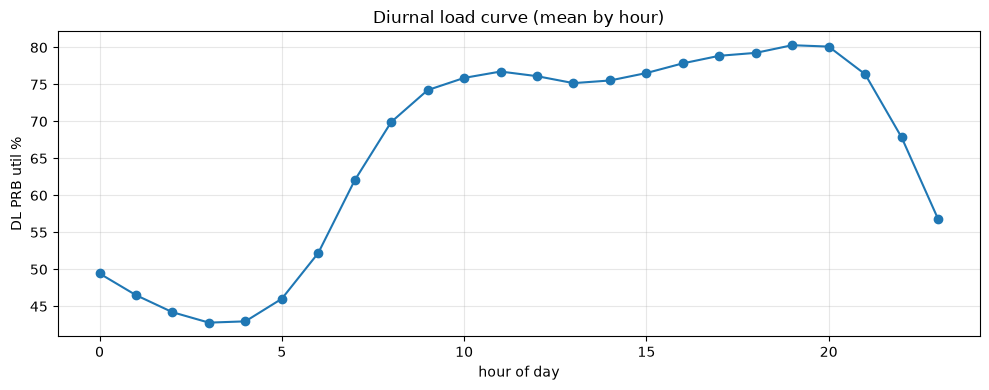

trough 42.8% @ h=3 | peak 80.3% @ h=19 | swing 37.5 pp
distinct hourly means (0.1pp): 24/24  -- 2 would mean a square wave, ~24 a smooth curve


In [7]:
# Diurnal curve -> motivates hour-of-day. Watch the SHAPE: a smooth rhythm or a step function?
diurnal = raw.groupby('hour')[TARGET].mean()
plt.figure(figsize=(10, 4))
plt.plot(diurnal.index, diurnal.values, 'o-')
plt.xlabel('hour of day'); plt.ylabel('DL PRB util %'); plt.title('Diurnal load curve (mean by hour)')
plt.grid(alpha=.3); plt.tight_layout(); plt.savefig(FIG_DIR / 'eda_diurnal.png', dpi=120); plt.show()

print('trough %.1f%% @ h=%d | peak %.1f%% @ h=%d | swing %.1f pp'
      % (diurnal.min(), diurnal.idxmin(), diurnal.max(), diurnal.idxmax(), diurnal.max() - diurnal.min()))
print('distinct hourly means (0.1pp): %d/24  -- 2 would mean a square wave, ~24 a smooth curve'
      % diurnal.round(1).nunique())

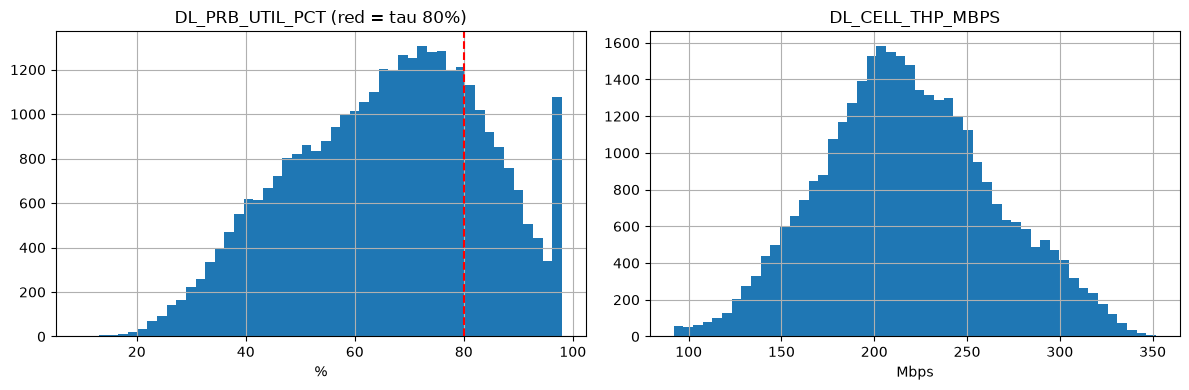

cell-steps above tau: 0.235


In [8]:
# Target distributions
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
raw[TARGET].hist(bins=50, ax=ax[0]); ax[0].axvline(TAU, color='r', ls='--')
ax[0].set_title(f'{TARGET} (red = tau {TAU:g}%)'); ax[0].set_xlabel('%')
raw[SECONDARY].hist(bins=50, ax=ax[1]); ax[1].set_title(SECONDARY); ax[1].set_xlabel('Mbps')
plt.tight_layout(); plt.savefig(FIG_DIR / 'eda_target_dist.png', dpi=120); plt.show()

print('cell-steps above tau: %.3f' % (raw[TARGET] > TAU).mean())

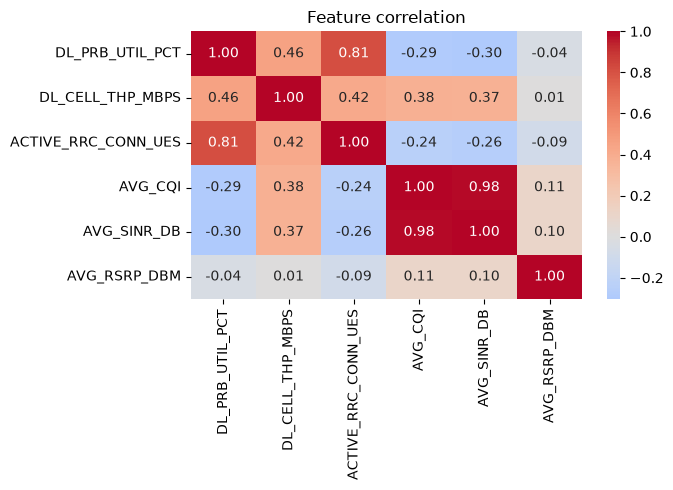

In [9]:
# Correlation heatmap -> flags SINR vs CQI redundancy (tested in 5.2)
cols = [TARGET, SECONDARY] + RADIO_KPIS
plt.figure(figsize=(7, 5))
sns.heatmap(raw[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature correlation'); plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_corr.png', dpi=120); plt.show()

---
## 2 - Features, temporal split, scaler

Builds the Δ=1 modelling frame used by 3, 5 and 6. The same functions are re-invoked with other Δ in 4, so every horizon stays leakage-safe by construction.

**Warm-up cost:** `lag_96` and `roll_mean_96` need a full day of history, so the first calendar day is
consumed and ~6 days survive. The split derives its cut points from the surviving days rather than
hard-coded indices.

In [10]:
df1, FEAT1 = engineer_features(raw.copy(), H=H_MAIN)
m1 = make_model_frame(df1, FEAT1)
print('rows: %d raw -> %d modelling (warm-up + imputed labels dropped)' % (len(raw), len(m1)))
print('n features:', len(FEAT1)); print(FEAT1)

tr, va, te, info = split_days(m1)
print('\ndays surviving warm-up:', info['days'])
print('val starts %s | test starts %s'
      % (pd.Timestamp(info['val_start']).date(), pd.Timestamp(info['test_start']).date()))
tot = len(m1)
print('train %d (%.0f%%) | val %d (%.0f%%) | test %d (%.0f%%)'
      % (len(tr), 100*len(tr)/tot, len(va), 100*len(va)/tot, len(te), 100*len(te)/tot))

m1.to_parquet(PROC_DIR / 'processed_panel.parquet')
print('saved -> data/processed_panel.parquet')

rows: 33600 raw -> 28588 modelling (warm-up + imputed labels dropped)
n features: 14
['hour_sin', 'hour_cos', 'roll_mean_4', 'roll_std_4', 'roll_mean_96', 'roc', 'lag_1', 'lag_2', 'lag_3', 'lag_96', 'ACTIVE_RRC_CONN_UES_lag1', 'AVG_CQI_lag1', 'AVG_SINR_DB_lag1', 'AVG_RSRP_DBM_lag1']

days surviving warm-up: ['2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-03', '2026-07-04']
val starts 2026-07-03 | test starts 2026-07-04
train 19055 (67%) | val 4770 (17%) | test 4763 (17%)
saved -> data/processed_panel.parquet


In [11]:
# Scaler fit on TRAIN ONLY. XGBoost does not need it (trees are scale-invariant);
# it is saved for the pooled sequence model in section 7.
from sklearn.preprocessing import StandardScaler
import joblib
scaler = StandardScaler().fit(tr[FEAT1])
joblib.dump(scaler, PROC_DIR / 'scaler_train.joblib')
print('scaler fit on train only -> saved data/scaler_train.joblib')

scaler fit on train only -> saved data/scaler_train.joblib


---
## 3 - Baselines and headline forecaster (RQ1, H1)

**Gate:** XGBoost must beat **persistence** *and* **seasonal-naive** on the held-out test day.
Persistence (y- = last observed) is the floor; seasonal-naive (y- = same time yesterday) is the real bar,
because a strong daily cycle makes it hard to beat.
Metrics are reported in original units — percentage points of PRB utilisation.

In [12]:
rows = []
for name, col in [('persistence', 'pred_persistence'), ('seasonal_naive', 'pred_seasonal')]:
    m = reg_metrics(te[TARGET], te[col])
    log_result(name, 'test', m, horizon=H_MAIN)
    rows.append({'model': name, **m})
pd.DataFrame(rows).set_index('model').round(3)

,MAE,RMSE,MAPE,R2
model,,,,
persistence,5.868,7.392,10.327,0.801
seasonal_naive,7.531,9.433,13.497,0.675


In [13]:
Xtr, Xva, Xte = add_cell(tr, FEAT1), add_cell(va, FEAT1), add_cell(te, FEAT1)
ytr, yva, yte = tr[TARGET], va[TARGET], te[TARGET]

xgb = new_xgb()
xgb.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
print('best_iteration:', xgb.best_iteration, '(early stopping chose this on the VALIDATION day)')

yhat_te = xgb.predict(Xte)
m_xgb = reg_metrics(yte, yhat_te)
log_result('xgboost', 'test', m_xgb, horizon=H_MAIN)
{k: round(v, 3) for k, v in m_xgb.items()}

best_iteration: 109 (early stopping chose this on the VALIDATION day)


{'MAE': 5.302, 'RMSE': 6.691, 'MAPE': 9.716, 'R2': 0.837}

### 3.1 Results table and the gate

`.last()` after sorting by `ts` means "latest run", and the frame is scoped to the dataset actually in
use

In [14]:
res = pd.read_csv(RESULTS_CSV)
res = res[(res['split'] == 'test') & (res['dataset'] == DATA_FILE) & (res['horizon'] == H_MAIN)]
tbl = (res.sort_values('ts').groupby('model')[['MAE', 'RMSE', 'MAPE', 'R2']].last()
       .reindex(['persistence', 'seasonal_naive', 'xgboost']))
print('dataset:', DATA_FILE); print(tbl.round(3))

xgb_mae = tbl.loc['xgboost', 'MAE']
beats = (xgb_mae < tbl.loc['persistence', 'MAE']) and (xgb_mae < tbl.loc['seasonal_naive', 'MAE'])
print('\nGATE:', 'PASS - XGBoost beats persistence AND seasonal-naive' if beats
      else 'FAIL - improve features before continuing')
print('improvement over seasonal-naive: %.1f%%'
      % (100 * (tbl.loc['seasonal_naive', 'MAE'] - xgb_mae) / tbl.loc['seasonal_naive', 'MAE']))

dataset: synthetic_realistic_v3_pm_data.csv
                  MAE   RMSE    MAPE      R2
model                                       
persistence     5.868  7.392  10.327  0.8006
seasonal_naive  7.531  9.433  13.497  0.6752
xgboost         5.302  6.691   9.716  0.8366

GATE: PASS - XGBoost beats persistence AND seasonal-naive
improvement over seasonal-naive: 29.6%


### 3.2 Predicted vs actual, and residuals

The trace is a qualitative check that the model tracks shape and timing. The residual plots are the
quantitative complement: they reveal **bias** (are errors centred on zero?) and **heteroscedasticity**
(does error grow with load?). The second matters directly — high load is exactly where τ-crossings
happen, so an error that widens there would undermine the congestion labels.

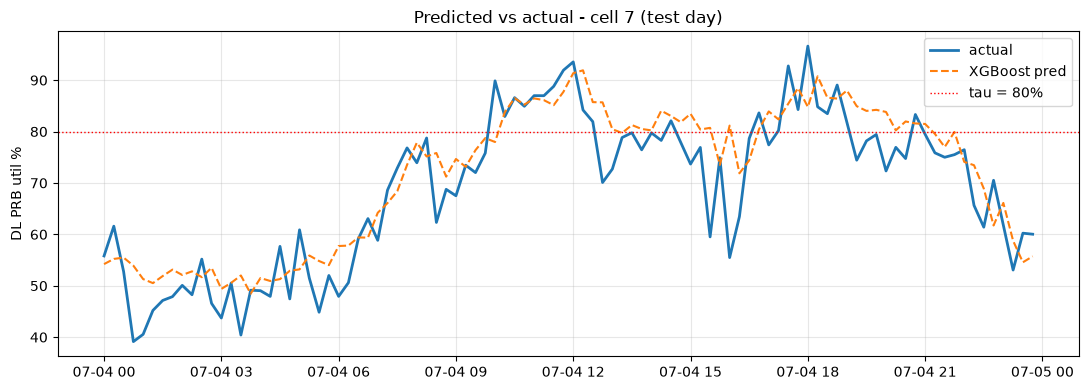

In [15]:
cid = te['cellId'].iloc[0]
sample = te[te['cellId'] == cid].copy()
sample['pred'] = xgb.predict(add_cell(sample, FEAT1))
plt.figure(figsize=(11, 4))
plt.plot(sample['startTime'], sample[TARGET], label='actual', lw=2)
plt.plot(sample['startTime'], sample['pred'], label='XGBoost pred', ls='--')
plt.axhline(TAU, color='r', ls=':', lw=1, label=f'tau = {TAU:g}%')
plt.title(f'Predicted vs actual - cell {cid} (test day)'); plt.ylabel('DL PRB util %')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(FIG_DIR / 'pred_vs_actual.png', dpi=120); plt.show()

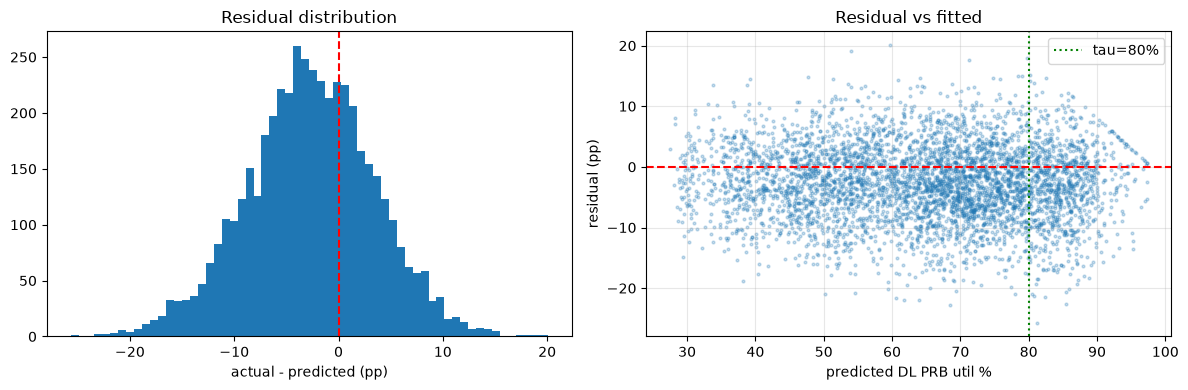

residual mean -2.679 pp (0 = unbiased) | std 6.131 pp
residual std below tau 6.02 | above tau 5.00  <- widening here would hurt the congestion labels
bias above tau: 1.50 pp (negative = under-predicting congestion)


In [16]:
resid = np.asarray(yte, float) - yhat_te
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(resid, bins=60, edgecolor='none')
ax[0].axvline(0, color='r', ls='--')
ax[0].set_title('Residual distribution'); ax[0].set_xlabel('actual - predicted (pp)')

ax[1].scatter(yhat_te, resid, s=4, alpha=.25)
ax[1].axhline(0, color='r', ls='--'); ax[1].axvline(TAU, color='g', ls=':', label=f'tau={TAU:g}%')
ax[1].set_xlabel('predicted DL PRB util %'); ax[1].set_ylabel('residual (pp)')
ax[1].set_title('Residual vs fitted'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG_DIR / 'residuals.png', dpi=120); plt.show()

print('residual mean %.3f pp (0 = unbiased) | std %.3f pp' % (resid.mean(), resid.std()))
hi, lo = resid[np.asarray(yte) > TAU], resid[np.asarray(yte) <= TAU]
if len(hi):
    print('residual std below tau %.2f | above tau %.2f  <- widening here would hurt the congestion labels'
          % (lo.std(), hi.std()))
    print('bias above tau: %.2f pp (negative = under-predicting congestion)' % hi.mean())

---
## 4 - Lead-time / horizon sweep (RQ1 + RQ4)

Δ is re-interpreted here as the **OSS collection latency the forecast must absorb**, not merely an
accuracy ablation.

The ROP is generated at the cell every 15 minutes — the sampling cadence is fine. The constraint is
downstream: each ROP must traverse network element → mediation → OSS before any controller can read it,
which takes on the order of an hour. A controller therefore acts on state that is already ~4 ROPs stale
and observes its action's effect ~4 ROPs later, with successive actions' effects overlapping.

That mis-specifies the `(s, a, r, s′)` transition tuple that online value-based RL depends on — and every
RL method in the reviewed literature (tabular Q-learning → DQN → hierarchical RL → multi-agent correlated
Q-learning) is exactly that kind. It is why the corpus is simulation-bound. *Sample volume is not the
issue*: 15-min ROP yields 96 transitions/cell/day, ≈1.75 M/year pooled over 50 cells.

A forecaster has no such problem: if the freshest observation is Δ_lat old, the object required is simply
a forecast at lead time ≥ Δ_lat. **Δ=4 (60 min) is therefore the operationally relevant point**, and Δ=8
(120 min) is the stress case. Features are shifted by Δ, so each point is operationally faithful.

**Persistence is logged at every Δ here, because it is the reactive baseline's information state.**
`pred_persistence = lag_Δ` — the freshest measurement a controller can hold when OSS delivery costs Δ
steps. The gap between the XGBoost curve and the persistence curve is therefore the prediction-vs-reaction
margin *in the prediction layer*, and §8 replays the same margin in the system layer. Reading the two
together is the point: Δ=1 is where the two estimators are most alike, so a tie there says little.

In [17]:
# Per-lead-time frames are CACHED: the steering layer (§8) and the seed sweep (§8.2) both need
# to refit at a chosen lead time, and rebuilding features is the expensive part.
FRAMES = {}          # h -> dict(feat, tr, va, te)
PRED_FRAMES = {}     # (forecaster, h) -> tidy [startTime, cellId, yhat], consumed by §8

hz_rows = []
for h in LEAD_TIMES:                     # note: `h`, not `H` - avoids shadowing H_MAIN
    dfh, FEATh = engineer_features(raw.copy(), H=h)
    mh = make_model_frame(dfh, FEATh)
    trh, vah, teh, _ = split_days(mh)
    FRAMES[h] = dict(feat=FEATh, tr=trh, va=vah, te=teh)

    mdl = new_xgb()
    mdl.fit(add_cell(trh, FEATh), trh[TARGET],
            eval_set=[(add_cell(vah, FEATh), vah[TARGET])], verbose=False)
    yh = mdl.predict(add_cell(teh, FEATh))
    # Hand the forecast to the steering layer. Previously the sweep threw its predictions away,
    # so §8 could only ever steer on the single Δ=1 model fitted in §3.
    PRED_FRAMES[('xgboost', h)] = teh[['startTime', 'cellId']].assign(yhat=yh)

    mx = reg_metrics(teh[TARGET], yh)
    ms = reg_metrics(teh[TARGET], teh['pred_seasonal'])
    mp = reg_metrics(teh[TARGET], teh['pred_persistence'])   # = the reactive information state
    log_result('xgboost', 'test', mx, horizon=h)
    log_result('seasonal_naive', 'test', ms, horizon=h)
    log_result('persistence', 'test', mp, horizon=h)

    # congestion-label quality at this lead time - what steering actually acts on
    lt, lp = (teh[TARGET].to_numpy() > TAU).astype(int), (yh > TAU).astype(int)
    f1 = f1_score(lt, lp, zero_division=0) if lt.sum() else np.nan
    hz_rows.append(dict(delta=h, minutes=15 * h, xgb_MAE=mx['MAE'], persist_MAE=mp['MAE'],
                        seasonal_MAE=ms['MAE'], xgb_R2=mx['R2'], congestion_F1=f1,
                        xgb_edge_pct=100 * (mp['MAE'] - mx['MAE']) / mp['MAE']))

hz = pd.DataFrame(hz_rows)
print(hz.round(3).to_string(index=False))
print('\n`xgb_edge_pct` = how much the forecast beats the freshest measurement available at that')
print('lead time. If it grows with Δ, prediction earns its keep precisely where latency bites.')

 delta  minutes  xgb_MAE  persist_MAE  seasonal_MAE  xgb_R2  congestion_F1  xgb_edge_pct
     1       15    5.302        5.868         7.531   0.837          0.713         9.643
     2       30    5.878        6.721         7.531   0.801          0.670        12.538
     4       60    6.224        7.929         7.531   0.779          0.663        21.505
     8      120    6.639       10.387         7.531   0.752          0.642        36.078

`xgb_edge_pct` = how much the forecast beats the freshest measurement available at that
lead time. If it grows with Δ, prediction earns its keep precisely where latency bites.


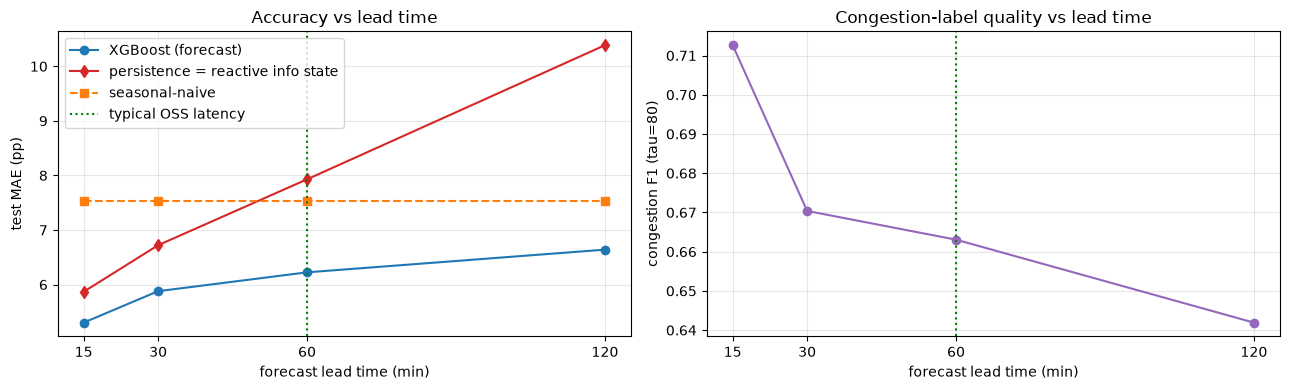

RQ4 read: the XGBoost-vs-persistence GAP is the quantity of interest, not the absolute MAE.
Persistence degrades as the measurement it relies on gets staler; a forecaster targets the
step it is asked about. A widening gap is prediction beating reaction under real latency.
CAVEAT: on the square-wave primary panel flatness is partly a data artifact -
        re-run on a synthetic_realistic_* panel before leaning on this result.


In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(hz['minutes'], hz['xgb_MAE'], 'o-', label='XGBoost (forecast)')
ax[0].plot(hz['minutes'], hz['persist_MAE'], 'd-', color='tab:red',
           label='persistence = reactive info state')
ax[0].plot(hz['minutes'], hz['seasonal_MAE'], 's--', label='seasonal-naive')
ax[0].axvline(15 * HEADLINE_LEAD, color='g', ls=':', label='typical OSS latency')
ax[0].set_xlabel('forecast lead time (min)'); ax[0].set_ylabel('test MAE (pp)')
ax[0].set_title('Accuracy vs lead time'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[0].set_xticks(hz['minutes'])

ax[1].plot(hz['minutes'], hz['congestion_F1'], 'o-', color='tab:purple')
ax[1].axvline(15 * HEADLINE_LEAD, color='g', ls=':')
ax[1].set_xlabel('forecast lead time (min)'); ax[1].set_ylabel('congestion F1 (tau=80)')
ax[1].set_title('Congestion-label quality vs lead time'); ax[1].grid(alpha=.3)
ax[1].set_xticks(hz['minutes'])
plt.tight_layout(); plt.savefig(FIG_DIR / 'horizon_curve.png', dpi=120); plt.show()

print('RQ4 read: the XGBoost-vs-persistence GAP is the quantity of interest, not the absolute MAE.')
print('Persistence degrades as the measurement it relies on gets staler; a forecaster targets the')
print('step it is asked about. A widening gap is prediction beating reaction under real latency.')
print('CAVEAT: on the square-wave primary panel flatness is partly a data artifact -')
print('        re-run on a synthetic_realistic_* panel before leaning on this result.')

---
## 5 - Feature study (RQ3)

Three questions: what does the model use, is any KPI redundant, and does spatial-neighbour information
help — the last being the recast of the mobility gap for per-cell aggregate data.

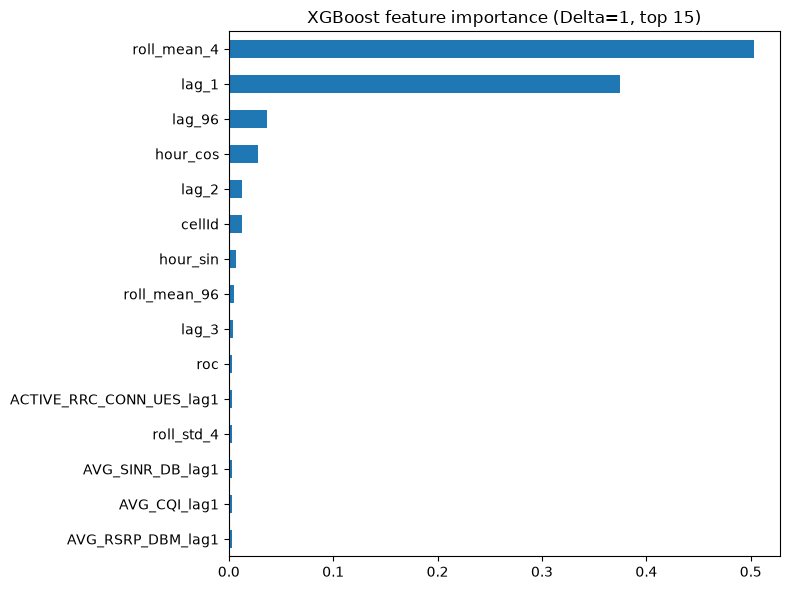

roll_mean_4                 0.503
lag_1                       0.374
lag_96                      0.037
hour_cos                    0.028
lag_2                       0.012
cellId                      0.012
hour_sin                    0.007
roll_mean_96                0.005
lag_3                       0.004
roc                         0.003
ACTIVE_RRC_CONN_UES_lag1    0.003
roll_std_4                  0.003
dtype: float32

In [19]:
# 5.1 Feature importance
imp = pd.Series(xgb.feature_importances_, index=Xtr.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6)); imp.head(15).iloc[::-1].plot.barh()
plt.title('XGBoost feature importance (Delta=1, top 15)'); plt.tight_layout()
plt.savefig(FIG_DIR / 'xgb_importance.png', dpi=120); plt.show()
imp.head(12).round(3)

In [20]:
# 5.2 SINR vs CQI redundancy -- drop-one refit. The KPI whose removal barely moves MAE is redundant.
def mae_with(features):
    mdl = new_xgb()
    mdl.fit(add_cell(tr, features), tr[TARGET],
            eval_set=[(add_cell(va, features), va[TARGET])], verbose=False)
    return reg_metrics(te[TARGET], mdl.predict(add_cell(te, features)))['MAE']

redun = pd.DataFrame({
    'feature_set': ['full', 'drop SINR', 'drop CQI'],
    'test_MAE': [mae_with(FEAT1),
                 mae_with([f for f in FEAT1 if 'SINR' not in f]),
                 mae_with([f for f in FEAT1 if 'CQI' not in f])]})
redun['delta_vs_full'] = redun['test_MAE'] - redun.loc[0, 'test_MAE']
print(redun.round(4).to_string(index=False))

feature_set  test_MAE  delta_vs_full
       full    5.3017         0.0000
  drop SINR    5.3039         0.0022
   drop CQI    5.3017        -0.0001


In [21]:
# 5.3 Neighbour-load ablation -- the spatial-aware result.
# Mean load of each cell's neighbours, shifted by 1 step so it stays leakage-safe.
load_wide = raw.pivot_table(index='startTime', columns='cellId', values=TARGET)
present = set(load_wide.columns)
nmap = {c: [n for n in g.sort_values('rank')['neighbourCellId'] if n in present]
        for c, g in nbr.groupby('cellId')}

nbr_feat = pd.DataFrame(index=load_wide.index)
for c in load_wide.columns:
    ns = nmap.get(c, [])
    nbr_feat[c] = load_wide[ns].mean(axis=1).shift(1) if ns else np.nan
nbr_long = nbr_feat.reset_index().melt(id_vars='startTime', var_name='cellId', value_name='nbr_load_lag1')

m1n = m1.merge(nbr_long, on=['startTime', 'cellId'], how='left')
trn = m1n[m1n['startTime'] < info['val_start']]
van = m1n[(m1n['startTime'] >= info['val_start']) & (m1n['startTime'] < info['test_start'])]
ten = m1n[m1n['startTime'] >= info['test_start']]
FEATn = FEAT1 + ['nbr_load_lag1']
for d in (trn, van, ten):
    d[FEATn] = d[FEATn].fillna(d['roll_mean_96'])       # guard any residual NaN

mdl = new_xgb()
mdl.fit(add_cell(trn, FEATn), trn[TARGET],
        eval_set=[(add_cell(van, FEATn), van[TARGET])], verbose=False)
mae_nbr = reg_metrics(ten[TARGET], mdl.predict(add_cell(ten, FEATn)))['MAE']
print('test MAE without neighbour load: %.4f' % m_xgb['MAE'])
print('test MAE WITH    neighbour load: %.4f' % mae_nbr)
print('=> neighbour load %s'
      % ('HELPS (lower MAE) - supports RQ3' if mae_nbr < m_xgb['MAE'] else 'does not help at this scale'))

test MAE without neighbour load: 5.3017
test MAE WITH    neighbour load: 5.1780
=> neighbour load HELPS (lower MAE) - supports RQ3


---
## 6 - Congestion derived from the forecast (RQ3)

Congestion is **not modelled separately**. The label is obtained by thresholding the prediction:
`z- = 1[y- > τ]`. This is the bridge from RQ1 to RQ2 — the steering policy acts on this label, so its
quality, not raw MAE, is what determines whether prediction can beat reaction.

Plain accuracy is deliberately not reported: with congestion at a low base rate, a model predicting
"never congested" would score highly while being useless. F1 and PR-AUC have no such failure mode.

**Read the persistence column, not the seasonal-naive one.** The reactive baseline B1 estimates
next-step load using the *current measured load* — which is exactly a persistence forecast. So the
quantity that bounds what prediction can contribute to a steering decision is

`F1(predicted > τ)  /  F1(persistence > τ)`

A ratio near 1.0 means the reactive baseline already produces the same congestion labels the
forecast would, leaving prediction no incremental information to act on. The larger the ratio, the
more the forecast sees that reaction does not.

Seasonal-naive is reported for reference only. It is *not* the comparator for RQ2: it is not the
estimator any policy uses, and on this panel it is weak for reasons unrelated to what B1 can see.

In [22]:
ytrue = te[TARGET].to_numpy()
ypers = te['pred_persistence'].to_numpy()   # == what the reactive baseline B1 uses
yseas = te['pred_seasonal'].to_numpy()      # reference only, not the RQ2 comparator

rows = []
for tau in [70, 80, 90]:
    lt = (ytrue > tau).astype(int)
    if lt.sum() == 0:
        rows.append(dict(tau=tau, positives=0)); continue
    lp = (yhat_te > tau).astype(int)
    lr = (ypers > tau).astype(int)
    ls = (yseas > tau).astype(int)
    rows.append(dict(tau=tau, positives=int(lt.sum()), base_rate=lt.mean(),
                     F1_model=f1_score(lt, lp, zero_division=0),
                     precision=precision_score(lt, lp, zero_division=0),
                     recall=recall_score(lt, lp, zero_division=0),
                     PR_AUC_model=average_precision_score(lt, yhat_te),
                     F1_persistence=f1_score(lt, lr, zero_division=0),
                     F1_seasonal=f1_score(lt, ls, zero_division=0)))
sweep = pd.DataFrame(rows)
print(sweep.round(3).to_string(index=False))

# Headroom over the estimator the REACTIVE policy actually uses.
r80 = sweep[sweep['tau'] == 80]
if len(r80) and r80['F1_persistence'].iloc[0] > 0:
    f1m = r80['F1_model'].iloc[0]; f1p = r80['F1_persistence'].iloc[0]
    print('\ncongestion F1 at tau=80: model %.3f | persistence (= B1 estimator) %.3f' % (f1m, f1p))
    print('headroom over the reactive baseline: %.2fx  (%+.1f%% absolute F1)'
          % (f1m / f1p, 100 * (f1m - f1p)))
    print('\nThis ratio bounds what prediction can add to a steering decision: near 1.0 means B1')
    print('already produces the same congestion labels. Compare it against the proposed-vs-B1')
    print('outcome in section 8 -- they should tell the same story. No fixed threshold is')
    print('asserted here; report the measured value alongside the steering result.')
else:
    print('\npersistence produced no positive congestion labels at tau=80; ratio undefined.')

 tau  positives  base_rate  F1_model  precision  recall  PR_AUC_model  F1_persistence  F1_seasonal
  70       1693      0.355     0.831      0.765   0.909         0.920           0.807        0.783
  80        706      0.148     0.713      0.626   0.827         0.777           0.667        0.612
  90        151      0.032     0.515      0.602   0.450         0.541           0.478        0.336

congestion F1 at tau=80: model 0.713 | persistence (= B1 estimator) 0.667
headroom over the reactive baseline: 1.07x  (+4.5% absolute F1)

This ratio bounds what prediction can add to a steering decision: near 1.0 means B1
already produces the same congestion labels. Compare it against the proposed-vs-B1
outcome in section 8 -- they should tell the same story. No fixed threshold is
asserted here; report the measured value alongside the steering result.


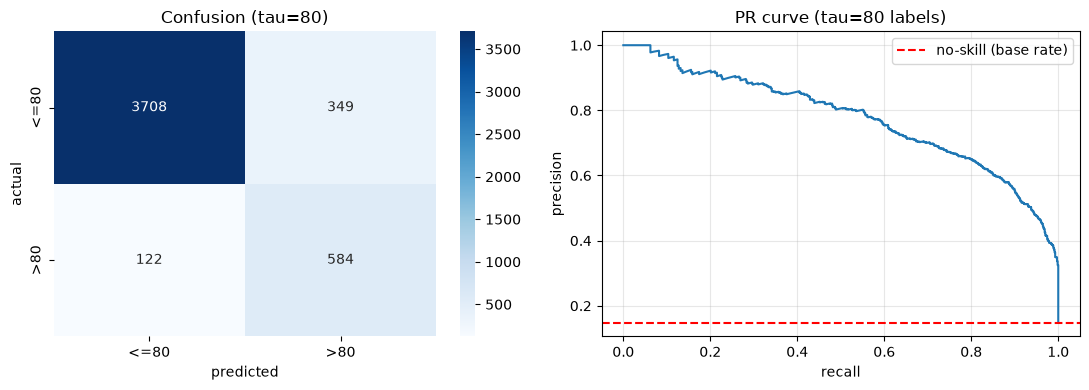

In [23]:
tau = 80
lt, lp = (ytrue > tau).astype(int), (yhat_te > tau).astype(int)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(confusion_matrix(lt, lp), annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['<=80', '>80'], yticklabels=['<=80', '>80'])
ax[0].set_title(f'Confusion (tau={tau})'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('actual')
if lt.sum() > 0:
    pr, rc, _ = precision_recall_curve(lt, yhat_te)
    ax[1].plot(rc, pr); ax[1].axhline(lt.mean(), color='r', ls='--', label='no-skill (base rate)')
    ax[1].set_xlabel('recall'); ax[1].set_ylabel('precision')
    ax[1].set_title('PR curve (tau=80 labels)'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG_DIR / 'congestion_threshold.png', dpi=120); plt.show()

---
## 7 - Pooled sequence model (RQ1, H1 comparison)

One **global** LSTM over all cells, with a `cellId` embedding so it can specialise per cell. Per-cell
deep learning is infeasible at 672 steps, hence pooling.

H1 predicts the sequence model beats XGBoost.

Windows never cross a split boundary, and the scaler is fit on **train windows only**.

Two sweeps run here, and they are **not** the same thing:

- **7.1 window sweep** (`w` = 24/48/96) at the primary lead time — how much *history* the model reads.
- **7.2 lead-time sweep** (Δ ∈ `LEAD_TIMES`) at the chosen window — how far *ahead* it must forecast.

Only 7.1 existed before, which meant the LSTM was never evaluated at any lead time but Δ=1, could not
be placed on the same axis as XGBoost's §4 curve, and — because its predictions were consumed inline and
never stored — could not reach the steering layer at all. Its test forecasts are now handed to §8, so the
choice of forecaster is a measured comparison rather than a printed remark.


In [24]:
SEQ_COLS = [TARGET] + RADIO_KPIS + ['hour_sin', 'hour_cos']

def make_windows(df_raw, w, H, val_start, test_start, cell_index):
    """Build (w-step window -> target at t) tensors per cell, respecting split boundaries."""
    from sklearn.preprocessing import StandardScaler
    df_raw = df_raw.sort_values(['cellId', 'startTime']).reset_index(drop=True)
    Xs, ys, cs, ts, ids = [], [], [], [], []
    for c in sorted(df_raw['cellId'].unique()):
        s = df_raw[df_raw['cellId'] == c]
        F = s[SEQ_COLS].to_numpy(float); y = s[TARGET].to_numpy(float)
        obs = s['target_observed'].to_numpy(bool); tt = s['startTime'].to_numpy(); n = len(s)
        for i in range(w + H - 1, n):
            if not obs[i]:                      # never train on an interpolated label
                continue
            win = F[i - H - w + 1:i - H + 1]    # window ends H steps before the target
            if win.shape[0] != w or np.isnan(win).any() or np.isnan(y[i]):
                continue
            Xs.append(win); ys.append(y[i]); cs.append(cell_index[c]); ts.append(tt[i])
            ids.append(c)                       # keep the real cellId, not just its embedding index
    X = np.asarray(Xs); y = np.asarray(ys); cid = np.asarray(cs); t = pd.to_datetime(np.asarray(ts))
    ids = np.asarray(ids)
    itr = t < pd.Timestamp(val_start)
    iva = (t >= pd.Timestamp(val_start)) & (t < pd.Timestamp(test_start))
    ite = t >= pd.Timestamp(test_start)
    sc = StandardScaler().fit(X[itr].reshape(-1, X.shape[-1]))   # TRAIN windows only
    scale = lambda a: sc.transform(a.reshape(-1, a.shape[-1])).reshape(a.shape)
    # `tte`/`idte` carry the test rows' (time, cell) identity out of the window builder. Without
    # them an LSTM forecast cannot be pivoted onto the steering grid, which is why the sequence
    # model previously dead-ended at a metrics row.
    return dict(Xtr=scale(X[itr]), ytr=y[itr], ctr=cid[itr],
                Xva=scale(X[iva]), yva=y[iva], cva=cid[iva],
                Xte=scale(X[ite]), yte=y[ite], cte=cid[ite],
                tte=t[ite], idte=ids[ite])

cell_index = {c: i for i, c in enumerate(sorted(raw['cellId'].unique()))}
print('window builder ready; %d cells' % len(cell_index))

window builder ready; 50 cells


In [25]:
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model, callbacks
    HAVE_TF = True
except Exception as e:
    HAVE_TF = False
    print('TensorFlow unavailable -> skipping sequence model:', e)

def build_seq_model(w, n_feat, n_cells, kind='LSTM', emb=8, units=64):
    seq_in = layers.Input(shape=(w, n_feat)); cid_in = layers.Input(shape=(1,), dtype='int32')
    rnn = layers.LSTM(units)(seq_in) if kind == 'LSTM' else layers.GRU(units)(seq_in)
    emb_v = layers.Flatten()(layers.Embedding(n_cells, emb)(cid_in))
    h = layers.Concatenate()([rnn, emb_v]); h = layers.Dense(32, activation='relu')(h)
    m = Model([seq_in, cid_in], layers.Dense(1)(h))
    m.compile(optimizer='adam', loss='mae')
    return m

def fit_seq(w, H, kind='LSTM', seed=SEED):
    """Fit one pooled sequence model and return (window bundle, test forecast, metrics)."""
    tf.random.set_seed(seed)
    d = make_windows(raw.copy(), w=w, H=H, val_start=info['val_start'],
                     test_start=info['test_start'], cell_index=cell_index)
    mdl = build_seq_model(w, len(SEQ_COLS), len(cell_index), kind=kind)
    es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    mdl.fit([d['Xtr'], d['ctr']], d['ytr'],
            validation_data=([d['Xva'], d['cva']], d['yva']),
            epochs=40, batch_size=256, verbose=0, callbacks=[es])
    yhat = mdl.predict([d['Xte'], d['cte']], verbose=0).ravel()
    return d, yhat, reg_metrics(d['yte'], yhat)

FORECASTERS = ['xgboost']            # every forecaster the steering layer will replay
HEADLINE_FC = 'xgboost'

if HAVE_TF:
    # --- 7.1 window sweep at the primary lead time -> choose w -------------------------
    sweep_rows, held = [], {}
    for w in [24, 48, 96]:                      # 6 h / 12 h / 24 h of history
        d, yhat, mk = fit_seq(w, H_MAIN)
        held[w] = (d, yhat)
        log_result(f'lstm_w{w}', 'test', mk, horizon=H_MAIN, extra={'window': w})
        sweep_rows.append(dict(window=w, **{k: round(v, 3) for k, v in mk.items()}))
        print('LSTM w=%d Δ=%d: MAE=%.3f RMSE=%.3f R2=%.3f' % (w, H_MAIN, mk['MAE'], mk['RMSE'], mk['R2']))

    lstm_tbl = pd.DataFrame(sweep_rows)
    W_BEST = int(lstm_tbl.loc[lstm_tbl['MAE'].idxmin(), 'window'])
    print('\n', lstm_tbl.to_string(index=False))
    print('chosen window w=%d' % W_BEST)

    # --- 7.2 lead-time sweep at the chosen window -------------------------------------
    # This is the axis that was missing. It puts the LSTM on the same footing as XGBoost's §4
    # curve and produces the forecasts §8 replays.
    for h in LEAD_TIMES:
        if h == H_MAIN:
            d, yhat = held[W_BEST]              # already fitted above, do not refit
        else:
            d, yhat, mk = fit_seq(W_BEST, h)
            log_result(f'lstm_w{W_BEST}', 'test', mk, horizon=h, extra={'window': W_BEST})
            print('LSTM w=%d Δ=%d: MAE=%.3f R2=%.3f' % (W_BEST, h, mk['MAE'], mk['R2']))
        PRED_FRAMES[('lstm', h)] = pd.DataFrame(
            {'startTime': d['tte'], 'cellId': d['idte'], 'yhat': yhat})

    # --- promotion: measured, not asserted --------------------------------------------
    # Previously this printed 'LSTM wins, promote it' and then steered on XGBoost regardless,
    # because nothing downstream read the result. Both forecasters now go through §8, and the
    # headline is whichever actually has the lower test MAE at the headline lead time.
    FORECASTERS = ['xgboost', 'lstm']
    lead_mae = {}
    for fc in FORECASTERS:
        f = PRED_FRAMES[(fc, HEADLINE_LEAD)].merge(
            FRAMES[HEADLINE_LEAD]['te'][['startTime', 'cellId', TARGET]], on=['startTime', 'cellId'])
        lead_mae[fc] = float((f[TARGET] - f['yhat']).abs().mean())
    HEADLINE_FC = min(lead_mae, key=lead_mae.get)
    print('\ntest MAE at the headline lead Δ=%d: %s' % (HEADLINE_LEAD,
          ' | '.join('%s %.3f' % kv for kv in lead_mae.items())))
    print('headline forecaster -> %s  (§8 replays BOTH; this only selects the headline row)'
          % HEADLINE_FC)
else:
    print('Install tensorflow, then re-run this cell for the sequence-model comparison.')
    print('Steering will proceed with XGBoost alone.')

I0000 00:00:1786041898.234877  574249 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786041898.235703  574249 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1786041900.257291  574249 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786041900.257820  574249 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


LSTM w=24 Δ=1: MAE=5.095 RMSE=6.433 R2=0.849


LSTM w=48 Δ=1: MAE=5.446 RMSE=6.841 R2=0.829


LSTM w=96 Δ=1: MAE=5.374 RMSE=6.746 R2=0.834

  window   MAE  RMSE  MAPE    R2
     24 5.095 6.433 9.326 0.849
     48 5.446 6.841 9.998 0.829
     96 5.374 6.746 9.714 0.834
chosen window w=24


LSTM w=24 Δ=2: MAE=5.303 R2=0.835


LSTM w=24 Δ=4: MAE=5.602 R2=0.818


LSTM w=24 Δ=8: MAE=6.005 R2=0.793

test MAE at the headline lead Δ=4: xgboost 6.224 | lstm 5.602
headline forecaster -> lstm  (§8 replays BOTH; this only selects the headline row)


---
## 8 - Prediction-based steering (RQ2, H2) — the central claim

Policies replayed over the test trace **at every lead time in `LEAD_TIMES`**, and for every forecaster
in `FORECASTERS`. At decision step *i* each policy decides how to relieve congestion at step *i+Δ*,
using only what it could actually know at *i*:

| Policy | Estimate used for step i+Δ | Target ranking |
|---|---|---|
| **B0** — strongest signal | last measured load, `A[i]` — **Δ steps stale** | neighbour RSRP, descending |
| **B1** — reactive | last measured load, `A[i]` — **Δ steps stale** | neighbour measured load, ascending |
| **Proposed** — predictive | **forecast** of `i+Δ` issued at *i* | coverage-eligible (`RSRP ≥ RSRP_MIN`), predicted load ascending |
| **Oracle** | *actual* `i+Δ` load | as proposed — the perfect-prediction ceiling |

**Why Δ now drives the baselines too.** Δ is the OSS collection latency (§4), so it sets every policy's
*information state*, not just the forecaster's target. A reactive controller acting on step *i+Δ* holds a
measurement taken Δ steps earlier — this is exactly `pred_persistence = lag_Δ` in the prediction layer.
The previous version fixed Δ=1 everywhere, which handed B0/B1 a measurement **four times fresher** than
the stated 60-minute latency permits, and compared them against a forecaster asked only for the next
15 minutes. That is the operating point where a forecast and a current measurement are most nearly the
same number, so a tie there was close to a foregone conclusion. Sweeping Δ is the fix.

**Common evaluation window.** All lead times are scored on the same timesteps (`EVAL0 = max(LEAD_TIMES)`
onward), because the longest lead time cannot act before then. Without this, Δ=1 and Δ=8 would be scored
on different traces and the comparison across Δ would be meaningless.

**Load-shift assumption (state explicitly).** When a cell's estimated load exceeds τ, the excess
(`load − τ`) is poured into neighbours in the policy's preference order, each target capped at τ, so
congestion is relieved rather than relocated. This is a deliberately simple fluid model. Planned
transfers are applied to the **actual** load matrix at *i+Δ*, so a policy steering on a bad estimate is
penalised by reality.

**Two caveats that must accompany any result from this section:**

1. **RSRP is a coverage proxy.** It is per-cell (averaged over served UEs), not per-link, so a
   neighbour's own `AVG_RSRP_DBM` stands in for the link the UE would get.
2. **The coverage constraint is applied asymmetrically.** Only proposed/oracle filter candidates by
   `RSRP ≥ RSRP_MIN`; B0 and B1 are never pruned by the floor. Proposed is therefore the only policy
   whose candidate set shrinks — part of any proposed-vs-B1 gap may be this constraint rather than
   forecast quality. This is unchanged and still open: re-run with the floor applied to B0/B1 before
   attributing the difference. Note it cuts *against* proposed, while the old fixed-Δ=1 bug cut *for*
   B1 — the two do not cancel in any knowable direction.

In [26]:
# Build the test trace. Measured quantities do not depend on the forecaster or the lead time,
# so LOAD / RSRP / THP are built once; only the forecast matrix varies per configuration.
def clean_pivot(frame, col):
    """time x cell matrix. A few (time,cell) bins are absent; NaN holes would poison sums,
    so interpolate along TIME within each cell."""
    m = frame.pivot_table(index='startTime', columns='cellId', values=col).sort_index()
    m = m.interpolate(axis=0, limit_direction='both')
    return m.fillna(m.stack().mean())

LOAD = clean_pivot(te, TARGET)              # measured load
RSRP = clean_pivot(te, 'AVG_RSRP_DBM')      # coverage proxy
THP  = clean_pivot(te, SECONDARY)           # measured throughput
cells, times = list(LOAD.columns), list(LOAD.index)
print('trace: %d timesteps x %d cells' % (len(times), len(cells)))

def pred_matrix(fc, h):
    """Forecast of load at time t, on exactly the same (time x cell) grid as LOAD."""
    m = (PRED_FRAMES[(fc, h)]
         .pivot_table(index='startTime', columns='cellId', values='yhat').sort_index()
         .reindex(index=LOAD.index, columns=LOAD.columns)
         .interpolate(axis=0, limit_direction='both'))
    return m.fillna(float(np.nanmean(LOAD.to_numpy())))

PREDS = {k: pred_matrix(*k) for k in PRED_FRAMES}
PRED = PREDS[('xgboost', H_MAIN)]           # kept so §3-§6 references still resolve
print('forecast matrices: %s' % sorted(PREDS))

# Sanity: every forecast grid must align with the measured grid, or steering would act on a
# different trace than it is scored against.
for k, M in PREDS.items():
    assert M.shape == LOAD.shape, f'{k}: forecast grid {M.shape} != load grid {LOAD.shape}'

NEIGH = {c: list(g.sort_values('rank')['neighbourCellId'])
         for c, g in nbr[nbr['cellId'].isin(cells) & nbr['neighbourCellId'].isin(cells)].groupby('cellId')}
print('cells with >=1 in-panel neighbour: %d/%d | avg candidates %.1f'
      % (len(NEIGH), len(cells), np.mean([len(v) for v in NEIGH.values()])))

trace: 96 timesteps x 50 cells
forecast matrices: [('lstm', 1), ('lstm', 2), ('lstm', 4), ('lstm', 8), ('xgboost', 1), ('xgboost', 2), ('xgboost', 4), ('xgboost', 8)]
cells with >=1 in-panel neighbour: 50/50 | avg candidates 8.0


In [27]:
def replay(policy, P=None, h=H_MAIN):
    """Decide at step i using only what is knowable at i, act on step i+h.

    `h` is the lead time AND the OSS collection latency, so it sets the INFORMATION STATE of every
    policy -- not just the forecaster's target. B0/B1 are reactive: the freshest measurement they
    can hold when acting on step i+h is A[i], taken h steps earlier. Fixing h=1 (the previous
    behaviour) gave them a measurement as fresh as the stated 60-min latency forbids.

    Returns the post-steering load matrix over the FULL trace (the caller slices to the common
    evaluation window) and the handover log.
    """
    A, R = LOAD.to_numpy(float), RSRP.to_numpy(float)
    Pm = (PRED if P is None else P).to_numpy(float)
    col = {c: j for j, c in enumerate(cells)}; T = len(times)
    out = A.copy(); handovers = []; last_move = {}
    for i in range(T - h):
        nxt = i + h
        est = A[i] if policy in ('B0', 'B1') else (Pm[nxt] if policy == 'proposed' else A[nxt])
        est_load = {c: est[col[c]] for c in cells}
        srcs = sorted([c for c in cells if est_load[c] > TAU], key=lambda c: -est_load[c])
        for c in srcs:
            rem = est_load[c] - TAU
            if rem <= 1e-6:
                continue
            cands = [n for n in NEIGH.get(c, []) if n in col]
            if policy == 'B0':
                order = sorted(cands, key=lambda n: -R[i][col[n]])
            elif policy == 'B1':
                order = sorted(cands, key=lambda n: est_load[n])
            else:                                    # proposed / oracle: coverage-constrained
                order = sorted([n for n in cands if R[i][col[n]] >= RSRP_MIN],
                               key=lambda n: est_load[n])
            for tgt in order:
                if rem <= 1e-6:
                    break
                room = TAU - est_load[tgt]
                if room <= 1e-6:
                    continue
                amt = min(rem, room)
                out[nxt, col[c]] -= amt; out[nxt, col[tgt]] += amt      # commit on ACTUAL i+h
                est_load[c] -= amt; est_load[tgt] += amt; rem -= amt
                pp = last_move.get((tgt, c), -99) >= i - 4              # reversal within 4 steps
                handovers.append(dict(t=i, target=nxt, src=c, tgt=tgt, amount=amt, pingpong=pp))
                last_move[(c, tgt)] = i
    out = np.clip(out, 0, 100)
    return pd.DataFrame(out, index=times, columns=cells), pd.DataFrame(handovers)

print('simulator ready (proactive: decide at i, relieve i+h; reactive policies are h steps stale)')

simulator ready (proactive: decide at i, relieve i+h; reactive policies are h steps stale)


### 8.1 System metrics

- **Throughput proxy** — served throughput scales with delivered load under a soft congestion penalty:
  `thp_proxy = THP × (1 − max(0, load−τ)/100)`. A congested cell serves at a penalised rate, so
  relieving congestion raises the aggregate. Reported as a gain relative to no steering.
- **Jain's fairness** of per-cell mean load (1 = perfectly even).
- **Congestion incidence** — fraction of cell-timesteps above τ.
- **Handovers / ping-pongs** — steering actions, and reversals within 4 steps.

Every metric is computed over the common evaluation window so rows are comparable across Δ, and
handovers are counted only where the acted-on step falls inside it.

In [28]:
# Common evaluation window: the longest lead time cannot act before step max(LEAD_TIMES), so every
# configuration is scored from there. Scoring Δ=1 over more steps than Δ=8 would confound the sweep.
EVAL0 = max(LEAD_TIMES)
LOAD1, THP1 = LOAD.iloc[EVAL0:], THP.iloc[EVAL0:]

def thp_proxy(Lmat):
    penalty = 1 - np.clip(Lmat.to_numpy() - TAU, 0, None) / 100.0
    return float((THP1.to_numpy() * penalty).sum())

base_thp = thp_proxy(LOAD1)

def metrics(Lmat, ho, name):
    L = Lmat.iloc[EVAL0:]
    if ho is None or ho.empty:
        n_ho = n_pp = 0
    else:
        inw = ho[ho['target'] >= EVAL0]          # only actions landing in the scored window
        n_ho, n_pp = len(inw), int(inw['pingpong'].sum())
    return dict(policy=name,
                thp_gain_pct=100 * (thp_proxy(L) - base_thp) / base_thp,
                jain_fairness=jains(L.mean(axis=0).to_numpy()),
                congestion_incidence=float((L.to_numpy() > TAU).mean()),
                handovers=n_ho, pingpongs=n_pp)

# Measurement-driven policies depend on Δ but NOT on which forecaster is used, so they are
# replayed once per Δ; `proposed` is replayed once per (forecaster, Δ).
# horizon 0 tags the do-nothing reference: it takes no action, so no lead time applies to it.
# (A NaN key here would be unindexable in the MultiIndex the table is built on.)
no_steer = metrics(LOAD, None, 'no_steering')
NO_STEER_CI = no_steer['congestion_incidence']
rows = [dict(horizon=0, model='none', **no_steer)]
Lmats = {}                                    # post-steering matrices at the headline config
for h in LEAD_TIMES:
    for pol, label, mdl_tag in [('B0', 'B0_rsrp', 'measured'),
                                ('B1', 'B1_reactive', 'measured'),
                                ('oracle', 'oracle', 'oracle')]:
        Lp, ho = replay(pol, h=h)
        m = metrics(Lp, ho, label)
        log_system(m, model=mdl_tag, horizon=h)
        rows.append(dict(horizon=h, model=mdl_tag, **m))
        if h == HEADLINE_LEAD:
            Lmats[label] = Lp
    for fc in FORECASTERS:
        Lp, ho = replay('proposed', P=PREDS[(fc, h)], h=h)
        m = metrics(Lp, ho, 'proposed')
        log_system(m, model=fc, horizon=h)
        rows.append(dict(horizon=h, model=fc, **m))
        if h == HEADLINE_LEAD and fc == HEADLINE_FC:
            Lmats['proposed'] = Lp

sysm = pd.DataFrame(rows).set_index(['horizon', 'model', 'policy']).sort_index()
print(sysm.round(3).to_string())
print('\nlogged %d policy rows -> %s' % (len(rows) - 1, SYS_CSV))

# The headline read: proposed vs the reactive baseline, at each lead time.
acted = pd.DataFrame(rows).query("policy != 'no_steering'")
piv = (acted.assign(key=lambda d: np.where(d['policy'] == 'proposed',
                                           'proposed:' + d['model'], d['policy']))
            .pivot_table(index='horizon', columns='key', values='congestion_incidence'))
print('no steering reference: congestion incidence %.4f' % NO_STEER_CI)
print('\n=== congestion incidence by lead time (lower is better) ===')
print(piv.round(4).to_string())
b1 = piv['B1_reactive']
for c in [c for c in piv.columns if c.startswith('proposed')]:
    print('%-22s vs B1: %s' % (c, ' '.join('Δ=%d %+.1f%%' % (h, 100 * (piv[c][h] - b1[h]) / b1[h])
                                           for h in piv.index)))
print('\nNegative = proposed relieves more congestion than reacting to a Δ-stale measurement.')

                              thp_gain_pct  jain_fairness  congestion_incidence  handovers  pingpongs
horizon model    policy                                                                              
0       none     no_steering         0.000          0.986                 0.162          0          0
1       lstm     proposed            0.460          0.992                 0.134        904          0
        measured B0_rsrp             0.354          0.991                 0.143        979          9
                 B1_reactive         0.447          0.993                 0.131        768          0
        oracle   oracle              0.966          0.991                 0.012        775          1
        xgboost  proposed            0.496          0.992                 0.128       1014          0
2       lstm     proposed            0.391          0.992                 0.137        888          0
        measured B0_rsrp             0.272          0.991                 0.145   

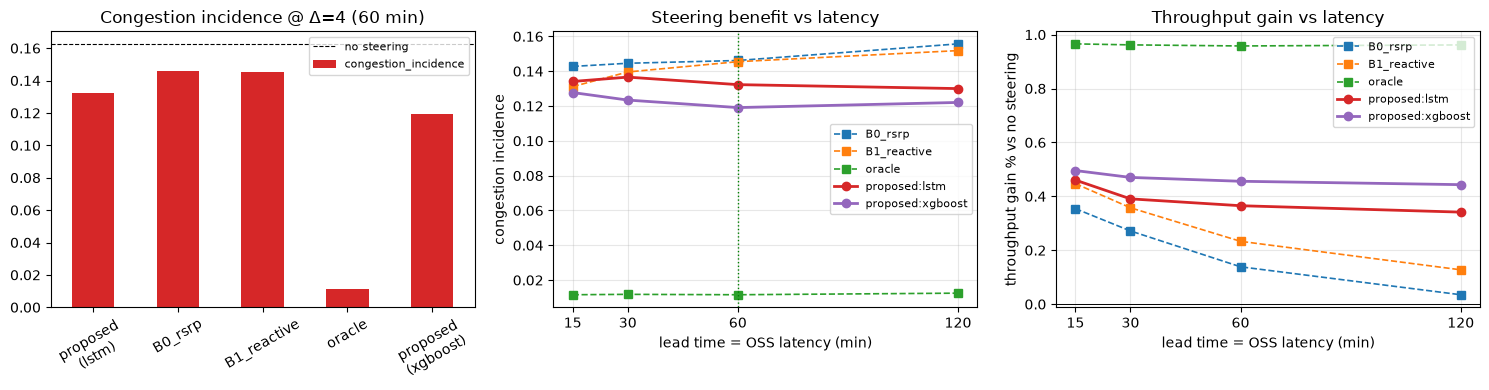

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# (a) policy comparison at the headline lead time
show = (sysm.xs(HEADLINE_LEAD, level='horizon')
            .reset_index().assign(label=lambda d: np.where(d['policy'] == 'proposed',
                                                           'proposed\n(' + d['model'] + ')',
                                                           d['policy']))
            .set_index('label'))
show['congestion_incidence'].plot.bar(ax=ax[0], color='tab:red')
ax[0].axhline(NO_STEER_CI, color='k', ls='--', lw=.8, label='no steering')
ax[0].set_title('Congestion incidence @ Δ=%d (%d min)' % (HEADLINE_LEAD, 15 * HEADLINE_LEAD))
ax[0].set_xlabel(''); ax[0].tick_params(axis='x', rotation=30); ax[0].legend(fontsize=8)

# (b) THE new result: does the proposed-vs-reactive gap open up as latency grows?
for c in piv.columns:
    sty = dict(marker='o', lw=2) if c.startswith('proposed') else dict(marker='s', ls='--', lw=1.2)
    ax[1].plot(15 * piv.index, piv[c], label=c, **sty)
ax[1].axvline(15 * HEADLINE_LEAD, color='g', ls=':', lw=1)
ax[1].set_xlabel('lead time = OSS latency (min)'); ax[1].set_ylabel('congestion incidence')
ax[1].set_title('Steering benefit vs latency'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
ax[1].set_xticks(15 * piv.index)

# (c) throughput gain across lead times
pv2 = (acted.assign(key=lambda d: np.where(d['policy'] == 'proposed',
                                           'proposed:' + d['model'], d['policy']))
            .pivot_table(index='horizon', columns='key', values='thp_gain_pct'))
for c in pv2.columns:
    sty = dict(marker='o', lw=2) if c.startswith('proposed') else dict(marker='s', ls='--', lw=1.2)
    ax[2].plot(15 * pv2.index, pv2[c], label=c, **sty)
ax[2].axhline(0, color='k', lw=.7); ax[2].set_xlabel('lead time = OSS latency (min)')
ax[2].set_ylabel('throughput gain % vs no steering')
ax[2].set_title('Throughput gain vs latency'); ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)
ax[2].set_xticks(15 * pv2.index)

plt.tight_layout(); plt.savefig(FIG_DIR / 'steering_system_metrics.png', dpi=120); plt.show()

### 8.2 Rigor: seed variance and significance

Three seeds for the forecaster, re-running the proposed policy each time, then a paired **Wilcoxon**
on per-timestep congested-cell count against B1. Both run at the **headline lead time**
(Δ = `HEADLINE_LEAD`), not at Δ=1, so the significance test addresses the operating point the thesis
actually claims.

The seed sweep refits **XGBoost** even when the LSTM is the headline forecaster: three sequence-model
refits cost minutes each and the variance being characterised is the forecaster-seed variance, which
XGBoost exhibits at a fraction of the cost. State that choice rather than implying all three seeds were
run for whichever model won.

In [30]:
def congested_per_step(Lmat):
    return (Lmat.iloc[EVAL0:].to_numpy() > TAU).sum(axis=1)

# Refit at the HEADLINE lead time, reusing the frames cached in §4.
fr = FRAMES[HEADLINE_LEAD]
seed_rows = []
for s in [42, 7, 123]:
    mdl = new_xgb(seed=s)
    mdl.fit(add_cell(fr['tr'], fr['feat']), fr['tr'][TARGET],
            eval_set=[(add_cell(fr['va'], fr['feat']), fr['va'][TARGET])], verbose=False)
    tes = fr['te'][['startTime', 'cellId']].assign(
        yhat=mdl.predict(add_cell(fr['te'], fr['feat'])))
    Pm = (tes.pivot_table(index='startTime', columns='cellId', values='yhat').sort_index()
             .reindex(index=LOAD.index, columns=LOAD.columns)
             .interpolate(axis=0, limit_direction='both'))
    Pm = Pm.fillna(float(np.nanmean(LOAD.to_numpy())))
    Lp, ho = replay('proposed', P=Pm, h=HEADLINE_LEAD)      # P passed explicitly - no global to restore
    m = metrics(Lp, ho, 'proposed'); seed_rows.append(dict(seed=s, **m))
    if s != SEED:
        log_system(m, seed=s, model='xgboost', horizon=HEADLINE_LEAD)

g = np.array([r['thp_gain_pct'] for r in seed_rows])
c = np.array([r['congestion_incidence'] for r in seed_rows])
print('seed sweep: XGBoost, Δ=%d (%d min)' % (HEADLINE_LEAD, 15 * HEADLINE_LEAD))
print(pd.DataFrame(seed_rows).round(4).to_string(index=False))
print('\nthroughput gain     %.2f%% +/- %.2f%%' % (g.mean(), g.std()))
print('congestion incidence %.4f +/- %.4f' % (c.mean(), c.std()))

seed sweep: XGBoost, Δ=4 (60 min)
 seed   policy  thp_gain_pct  jain_fairness  congestion_incidence  handovers  pingpongs
   42 proposed        0.4559         0.9933                0.1191       1281          0
    7 proposed        0.4585         0.9934                0.1218       1266          0
  123 proposed        0.4584         0.9933                0.1209       1276          0

throughput gain     0.46% +/- 0.00%
congestion incidence 0.1206 +/- 0.0011


In [31]:
prop_cs, b1_cs = congested_per_step(Lmats['proposed']), congested_per_step(Lmats['B1_reactive'])
print('comparison at Δ=%d (%d min), forecaster=%s' % (HEADLINE_LEAD, 15 * HEADLINE_LEAD, HEADLINE_FC))
if np.any(prop_cs - b1_cs != 0):
    stat, p = wilcoxon(prop_cs, b1_cs)
    print('Wilcoxon proposed vs B1 (congested cells/step): stat=%.1f p=%.4g' % (stat, p))
    print('median congested/step -> proposed %.1f | B1 %.1f' % (np.median(prop_cs), np.median(b1_cs)))
    print('verdict:', 'significant at 0.05' if p < 0.05 else 'NOT significant - report the null honestly')
    log_stat('wilcoxon_signed_rank',
             'proposed_vs_B1_congested_cells_per_step_lead%d_%s' % (HEADLINE_LEAD, HEADLINE_FC),
             stat, p, len(prop_cs))
else:
    print('proposed and B1 identical on congested-cell count (no steering headroom at this tau)')

comparison at Δ=4 (60 min), forecaster=lstm
Wilcoxon proposed vs B1 (congested cells/step): stat=288.5 p=0.000643
median congested/step -> proposed 6.0 | B1 7.5
verdict: significant at 0.05


---
## 9 - Consolidated results

Both metric layers, filtered to the dataset in use. `results.csv` and `system_results.csv` are
append-only across runs, so grouping takes the latest entry per configuration.

In [32]:
res = pd.read_csv(RESULTS_CSV)
view = (res[(res['split'] == 'test') & (res['dataset'] == DATA_FILE)]
        .sort_values('ts')
        .groupby(['model', 'horizon', 'window'], dropna=False)[['MAE', 'RMSE', 'MAPE', 'R2']].last()
        .reset_index().sort_values(['horizon', 'MAE']))
print('=== PREDICTION LAYER (%s) ===' % DATA_FILE)
print(view.round(3).to_string(index=False))

if SYS_CSV.exists():
    sysr = pd.read_csv(SYS_CSV)
    sv = (sysr[(sysr['dataset'] == DATA_FILE) & (sysr['seed'] == SEED)].sort_values('ts')
          .groupby(['horizon', 'model', 'policy'])[['thp_gain_pct', 'jain_fairness',
                                                    'congestion_incidence', 'handovers',
                                                    'pingpongs']].last())
    print('\n=== SYSTEM LAYER (%s, tau=%g, rsrp_min=%g, seed=%d) ===' % (DATA_FILE, TAU, RSRP_MIN, SEED))
    print(sv.round(3).to_string())
    print('\nRows are (lead time x estimator x policy). `model` = which estimator drove the policy:')
    print("  'measured' = B0/B1 read a Δ-stale measurement, 'oracle' = perfect foresight,")
    print('  otherwise the named forecaster supplied the prediction.')

=== PREDICTION LAYER (synthetic_realistic_v3_pm_data.csv) ===
         model  horizon window    MAE   RMSE   MAPE     R2
      lstm_w24      1.0     24  5.031  6.350  9.170 0.8528
       xgboost      1.0    NaN  5.302  6.691  9.716 0.8366
      lstm_w48      1.0     48  5.372  6.755  9.800 0.8334
      lstm_w96      1.0     96  5.377  6.758  9.759 0.8333
   persistence      1.0    NaN  5.868  7.392 10.327 0.8006
seasonal_naive      1.0    NaN  7.531  9.433 13.497 0.6752
      lstm_w24      2.0     24  5.303  6.718  9.663 0.8352
       xgboost      2.0    NaN  5.878  7.389 10.720 0.8007
   persistence      2.0    NaN  6.721  8.496 11.827 0.7365
seasonal_naive      2.0    NaN  7.531  9.433 13.497 0.6752
      lstm_w24      4.0     24  5.602  7.058 10.190 0.8182
       xgboost      4.0    NaN  6.224  7.782 11.300 0.7789
seasonal_naive      4.0    NaN  7.531  9.433 13.497 0.6752
   persistence      4.0    NaN  7.929  9.962 13.928 0.6377
      lstm_w24      8.0     24  6.005  7.529 10.828 0